# Day 7 : Classification and Binary Prediction (Titanic)

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

df = pd.read_csv('train.csv')

## Question 1

In [122]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [123]:
survived = df['Survived'].sum()
total_count = len(df)
print(f"1. Total Passengers = {total_count}")
print(f"2. Survived Count = {survived}")
print(f"3. Died Count = {total_count-survived}")
print(f"4. Survived Percent = {round(survived*100/total_count,2)}")
print("\nNo the dataset is not balanced as the target variable has more 0 than 1, which means it shows a bias to the 0 class")

1. Total Passengers = 891
2. Survived Count = 342
3. Died Count = 549
4. Survived Percent = 38.38

No the dataset is not balanced as the target variable has more 0 than 1, which means it shows a bias to the 0 class


## Question 2

In [124]:
X = df[['Pclass','Age','Fare','SibSp','Parch']].copy()
y = df['Survived'].copy()

print(X.shape)
print(y.shape)

(891, 5)
(891,)


## Question 3

In [125]:
print(f"Before Handling : \n{X.isna().sum()}\n")
X['Median_Age'] = X.groupby('Pclass')['Age'].transform('median')
X['Age'].fillna(X['Median_Age'], inplace=True)
print(f"After handling: \n{X.isna().sum()}")
X.drop(columns=['Median_Age'],inplace=True)

Before Handling : 
Pclass      0
Age       177
Fare        0
SibSp       0
Parch       0
dtype: int64

After handling: 
Pclass        0
Age           0
Fare          0
SibSp         0
Parch         0
Median_Age    0
dtype: int64


## Question 4

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 5)
(179, 5)


## Question 5

In [127]:
model = LogisticRegression()
model.fit(X_train,y_train)

print('We use Logistic Regression because we are trying to classify our dataset into 2 distinct outputs and not predict any mathematical value')

We use Logistic Regression because we are trying to classify our dataset into 2 distinct outputs and not predict any mathematical value


## Question 6

In [128]:
y_pred = model.predict(X_test)
predictions = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
# predictions["Actual"] = y_test
# predictions['Prediction'] = y_pred
predictions.iloc[:10]


,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,0
290,1,1
300,1,0
333,0,0
208,1,0
136,1,1


## Question 7

In [129]:
y_true = np.array(y_test)
accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
print(f"Accuracy = {accuracy}")
print("\nAccuracy indicates the number of true positives from total classifications.")
## Correction : It is the percentage of all predictions that were correct = (tp+tn)/(tp+tn+fp+fn)


Accuracy = 0.7318435754189944

Accuracy indicates the number of true positives from total classifications.


## Question 8

Confusion Matrix =
[[94 11]
 [37 37]]
False Positives occur most often


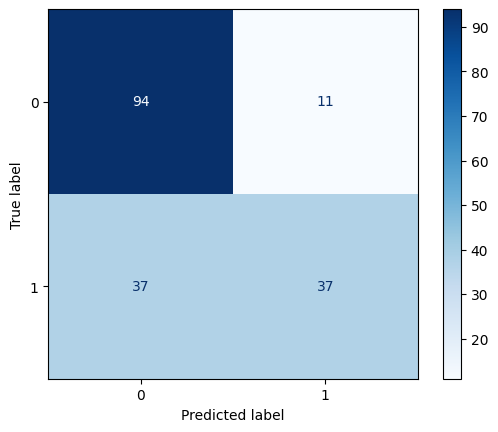

In [130]:
cm = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix =\n{cm}")
print('False Positives occur most often') ## Correction : It asked for most in this cm dumbass :facepalm:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Question 9

In [131]:
precision = precision_score(y_true,y_pred)
recall = recall_score(y_true,y_pred)
print(f"Precision = {precision}")
print(f"Recall = {recall}")

print("\nFor medical diagnosis, precision score would be more important whereas for Spam detection it would be recall\n" \
"Its because for medical diagnosis, quality of positive outputs is more important than the quantity or repetition." \
"\nWhereas for spam detection, we would want to know the maximum number of spam in all of our data, \nbecause false negatives in this case would be harmful")

'''
Correction:
For medical, Recall would be better because what if we miss out a cancer patient lol.
For spam, apparently precision is better, cuz putting a real email in spam is annoying. looks like i reversed the 2 lol.
'''

Precision = 0.7708333333333334
Recall = 0.5

For medical diagnosis, precision score would be more important whereas for Spam detection it would be recall
Its because for medical diagnosis, quality of positive outputs is more important than the quantity or repetition.
Whereas for spam detection, we would want to know the maximum number of spam in all of our data, 
because false negatives in this case would be harmful


'\nCorrection:\nFor medical, Recall would be better because what if we miss out a cancer patient lol.\nFor spam, apparently precision is better, cuz putting a real email in spam is annoying. looks like i reversed the 2 lol.\n'

## Question 10

1. Our model has an accuracy of about 75% along with a precision of 77% which shows us that it is above average at predicting the survivors giving us a 77% of confidence of true positives.
2. Since our recall is still just 50% it is a coin flip for any false negatives, so there is a posibility that the model is classifying some survivors as dead.
3. A feature which i would include is 'Sex' as i think it would make an impact on the outcome of the model and improve its accuracy if used into the training set.
4. Like we had seen earlier, the training data had more 0s than 1s which could possibly introduce training bias towards 0s which in turn solidifies our point about false negatives.
5. To improve the model, we could add more features, handle the class imbalance, possibly use a better classification model.

## DSA Question

In [ ]:
s = 'listen'
t = 'silent'

# check = {}

# if len(s) != len(t):
#     print(False)
# else:
#     for i, c in enumerate(s):
#         if c in check:

# Okay i dont know how to do this at all lmaoo 


## Basic Hashmap
freq = {}

for char in s:
    freq[char] = freq.get(char,0)+1
print(freq)


## Final Answer

def is_anagram(s,t):
    if len(s) != len(t):
        return False
    freq={}
    for char in s:
        freq[char] = freq.get(char,0)+1
    for char in t:
        if char not in freq:
            return False
        freq[char] -= 1
        if freq[char]<0:
            return False
    return True

print(is_anagram(s,t))


## Python built in tool

from collections import Counter

def anagram (s,t):
    return Counter(s)==Counter(t)

{'l': 1, 'i': 1, 's': 1, 't': 1, 'e': 1, 'n': 1}
True


In [135]:
print("1. Probably nested loops iterating through each string and checking for the characters") ## 0(n^2)
print("2. Hashmap i guess, i dont know how hashmaps works to be honest.") ## O(n)
print("3. I dont know, maybe O(logn)??")
print("4. No idea bout this either but maybe O(n^2)") ## O(n)

1. Probably nested loops iterating through each string and checking for the characters
2. Hashmap i guess, i dont know how hashmaps works to be honest.
3. I dont know, maybe O(logn)??
4. No idea bout this either but maybe O(n^2)
